In [1]:
import os
import sys
import json
import pandas as pd
import networkx as nx
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display, Image
import math
# Add project root to path
ROOT_DIR = Path(__file__).resolve().parent if '__file__' in locals() else Path().resolve().parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

print(ROOT_DIR)

/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization


In [12]:
from src.cut_algorithms.boykov_jolly import BoykovJollyCut
from src.cut_algorithms.data_parsers import compute_method_tarantula

In [13]:
bug_dir = ROOT_DIR / "data" / "defects4j" / "Lang_1" 
coverage_csv = bug_dir / "coverage.csv"
graph_json = bug_dir / "call_graph.json"
buggy_methods_file = bug_dir / "buggy_methods.txt"

In [14]:
df = pd.read_csv(coverage_csv)
df

,org.apache.commons.lang3$StringUtils#StringUtils():192,org.apache.commons.lang3$StringUtils#StringUtils():193,org.apache.commons.lang3$StringUtils#isEmpty(java.lang.CharSequence):217,org.apache.commons.lang3$StringUtils#isNotEmpty(java.lang.CharSequence):236,org.apache.commons.lang3$StringUtils#isBlank(java.lang.CharSequence):257,org.apache.commons.lang3$StringUtils#isBlank(java.lang.CharSequence):258,org.apache.commons.lang3$StringUtils#isBlank(java.lang.CharSequence):260,org.apache.commons.lang3$StringUtils#isBlank(java.lang.CharSequence):261,org.apache.commons.lang3$StringUtils#isBlank(java.lang.CharSequence):262,org.apache.commons.lang3$StringUtils#isBlank(java.lang.CharSequence):265,...,org.apache.commons.lang3$BooleanUtils#xor(boolean[]):1060,org.apache.commons.lang3$BooleanUtils#xor(java.lang.Boolean[]):1079,org.apache.commons.lang3$BooleanUtils#xor(java.lang.Boolean[]):1080,org.apache.commons.lang3$BooleanUtils#xor(java.lang.Boolean[]):1082,org.apache.commons.lang3$BooleanUtils#xor(java.lang.Boolean[]):1083,org.apache.commons.lang3$BooleanUtils#xor(java.lang.Boolean[]):1086,org.apache.commons.lang3$BooleanUtils#xor(java.lang.Boolean[]):1087,org.apache.commons.lang3$BooleanUtils#xor(java.lang.Boolean[]):1088,org.apache.commons.lang3$BooleanUtils#xor(java.lang.Boolean[]):1089,Result
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
4,0,0,0,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2268,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2269,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2270,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2271,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass


In [15]:
df.shape

(2273, 11716)

In [16]:
with open(graph_json, 'r') as f:
    graph_data = json.load(f)

G = nx.DiGraph()
for edge in graph_data['edges']:
    caller = edge['caller'].replace('$', '.')
    callee = edge['callee'].replace('$', '.')
    G.add_edge(caller, callee, frequency=float(edge['frequency']))

for node in graph_data.get('nodes', []):
    n_clean = node.replace('$', '.')
    if n_clean not in G:
        G.add_node(n_clean)

In [17]:
len(G.nodes), len(G.edges)

(134, 129)

# Computing Raw SBFL rankings per node

In [8]:
graph_data

{'metadata': {'total_nodes': 134, 'total_edges': 129},
 'nodes': ['org.apache.commons.lang3.math.NumberUtilsTest#testMinDouble_emptyArray()',
  'org.apache.commons.lang3.math.NumberUtils#toDouble(java.lang.String)',
  'org.apache.commons.lang3.math.NumberUtilsTest#testMaxFloat()',
  'org.apache.commons.lang3.math.NumberUtilsTest#testMaxLong_emptyArray()',
  'org.apache.commons.lang3.math.NumberUtilsTest#testMaxDouble_emptyArray()',
  'org.apache.commons.lang3.math.NumberUtils#isNumber(java.lang.String)',
  'org.apache.commons.lang3.math.NumberUtils#createDouble(java.lang.String)',
  'org.apache.commons.lang3.math.NumberUtils#createBigInteger(java.lang.String)',
  'org.apache.commons.lang3.math.NumberUtils#max(float[])',
  'org.apache.commons.lang3.math.NumberUtilsTest#testMaximumShort()',
  'org.apache.commons.lang3.math.NumberUtilsTest#testCreateNumber()',
  'org.apache.commons.lang3.math.NumberUtilsTest#testStringToDoubleStringD()',
  'org.apache.commons.lang3.math.NumberUtils#create

In [18]:
tarantula = compute_method_tarantula(coverage_csv)
len(tarantula)

2430

In [10]:
[key for key in tarantula.keys() if key not in graph_data['nodes']]

['org.apache.commons.lang3.StringUtils#StringUtils()',
 'org.apache.commons.lang3.StringUtils#isNotEmpty(java.lang.CharSequence)',
 'org.apache.commons.lang3.StringUtils#isNotBlank(java.lang.CharSequence)',
 'org.apache.commons.lang3.StringUtils#trim(java.lang.String)',
 'org.apache.commons.lang3.StringUtils#trimToNull(java.lang.String)',
 'org.apache.commons.lang3.StringUtils#trimToEmpty(java.lang.String)',
 'org.apache.commons.lang3.StringUtils#strip(java.lang.String)',
 'org.apache.commons.lang3.StringUtils#stripToNull(java.lang.String)',
 'org.apache.commons.lang3.StringUtils#stripToEmpty(java.lang.String)',
 'org.apache.commons.lang3.StringUtils#strip(java.lang.String,java.lang.String)',
 'org.apache.commons.lang3.StringUtils#stripStart(java.lang.String,java.lang.String)',
 'org.apache.commons.lang3.StringUtils#stripEnd(java.lang.String,java.lang.String)',
 'org.apache.commons.lang3.StringUtils#stripAll(java.lang.String[])',
 'org.apache.commons.lang3.StringUtils#stripAll(java.lan

In [22]:
cut_algo = BoykovJollyCut(G, tarantula)

In [23]:
cut_algo

In [24]:
cut_scores = []
for node in cut_algo.nodes:
    e0, e1 = cut_algo.compute_min_marginals(node)
    confidence = e0 - e1 # Higher is more buggy
    cut_scores.append({"Method": node, "GraphCut_Score": confidence})

In [26]:
cut_df = pd.DataFrame(cut_scores)
cut_df

,Method,GraphCut_Score
0,org.apache.commons.lang3.math.NumberUtilsTest#...,-1.000000e+09
1,org.apache.commons.lang3.math.NumberUtils#crea...,5.531191e+00
2,org.apache.commons.lang3.math.NumberUtilsTest#...,-1.000000e+09
3,org.apache.commons.lang3.math.NumberUtils#min(...,-1.000000e+09
4,org.apache.commons.lang3.math.NumberUtilsTest#...,-1.000000e+09
...,...,...
129,org.apache.commons.lang3.math.NumberUtilsTest#...,-1.000000e+09
130,org.apache.commons.lang3.math.NumberUtilsTest#...,-1.000000e+09
131,org.apache.commons.lang3.math.NumberUtilsTest#...,-1.000000e+09
132,org.apache.commons.lang3.math.NumberUtils#crea...,6.342121e+00


In [ ]:
sbfl_df = pd.DataFrame(extraction_res.sbfl_metrics)

In [28]:
merged_df = pd.merge(tarantula, cut_df, on="Method", how="left")
merged_df["GraphCut_Score"] = merged_df["GraphCut_Score"].fillna(-float('inf'))

buggy_set = set(extraction_res.buggy_methods)
# extraction_res.buggy_methods does not contain arguments, so we strip them from m for comparison
merged_df["Is_Buggy"] = merged_df["Method"].apply(lambda m: m.split('(')[0] in buggy_set)

TypeError: Can only merge Series or DataFrame objects, a <class 'dict'> was passed

In [31]:
ROOT_DIR = Path(os.getcwd())
sys.path.insert(0, str(ROOT_DIR / "src"))

from graph_generation.sbfl.extractor import SBFLGraphExtractor
from visualization.graph_plots import plot_json_graph
from cut_algorithms.boykov_jolly import BoykovJollyCut
from cut_algorithms.data_parsers import read_call_graph

extraction_res = extractor.extract(project, bug_id, str(output_dir), package_prefix)

ModuleNotFoundError: No module named 'graph_generation'

In [41]:
import os
import sys
import logging
from pathlib import Path
import pandas as pd

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

ROOT_DIR = Path(os.getcwd())
sys.path.insert(0, str(ROOT_DIR / "src"))

from src.benchmarking.sbfl_metrics import compute_sbfl_scores_from_csv
from src.visualization.graph_plots import plot_json_graph
from src.cut_algorithms.boykov_jolly import BoykovJollyCut
from src.cut_algorithms.data_parsers import read_call_graph

def get_best_rank(df: pd.DataFrame, score_col: str) -> int:
    sorted_df = df.sort_values(by=score_col, ascending=False).reset_index(drop=True)
    sorted_df['Rank'] = sorted_df[score_col].rank(method='min', ascending=False)
    buggy_ranks = sorted_df[sorted_df['Is_Buggy']]['Rank']
    return int(buggy_ranks.min())

folder_path = Path("/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Lang_1")
if not folder_path.exists() or not folder_path.is_dir():
    raise NotADirectoryError(f"Directory not found: {folder_path}")

call_graph_json = folder_path / "call_graph.json"
coverage_csv = folder_path / "coverage.csv"
buggy_txt = folder_path / "buggy_methods.txt"

if not call_graph_json.exists():
    raise FileNotFoundError(f"Missing file: {call_graph_json}")
if not coverage_csv.exists():
    raise FileNotFoundError(f"Missing file: {coverage_csv}")
if not buggy_txt.exists():
    raise FileNotFoundError(f"Missing file: {buggy_txt}")

In [42]:
logging.info(f"Processing folder: {folder_path.name}")

# Read buggy methods
with open(buggy_txt, 'r') as f:
    buggy_set = set([line.strip() for line in f if line.strip()])

# Compute SBFL scores
logging.info("Computing SBFL scores from coverage.csv...")
sbfl_df = compute_sbfl_scores_from_csv(str(coverage_csv))

tarantula_scores = dict(zip(sbfl_df["Method"], sbfl_df["Tarantula"]))

2026-06-17 15:02:33,526 - root - INFO - Processing folder: Lang_1
2026-06-17 15:02:33,530 - root - INFO - Computing SBFL scores from coverage.csv...


2026-06-17 15:02:53,246 - root - INFO - Visualizing Lang_1 Call Graph...


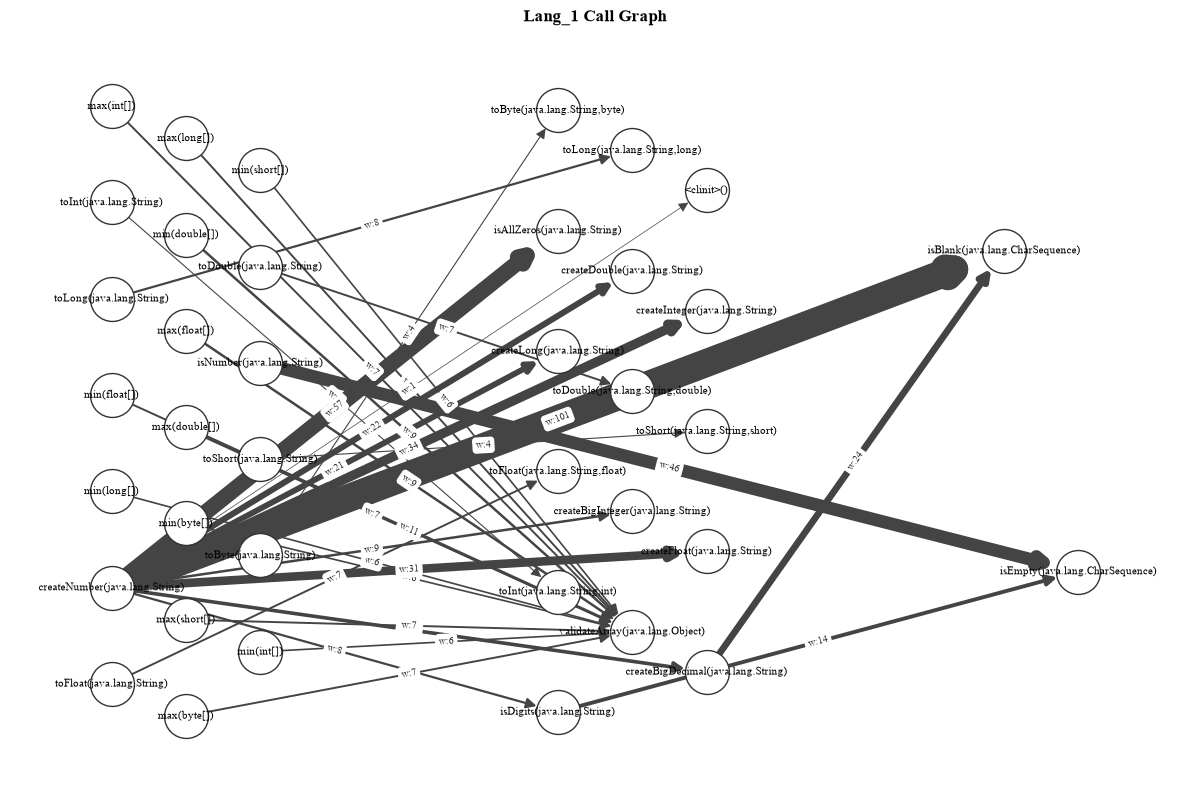

In [44]:
# Plot JSON Graph
plot_title = f"{folder_path.name} Call Graph"
save_prefix = str(folder_path / "call_graph_pregenerated")
logging.info(f"Visualizing {plot_title}...")
plot_json_graph(str(call_graph_json), plot_title)

In [46]:
# Compute Graph Cuts
logging.info("Loading graph and computing cuts...")
G = read_call_graph(str(call_graph_json))
cut_algo = BoykovJollyCut(G, tarantula_scores, lambd=1.0)

cut_scores = []
for node in cut_algo.nodes:
    e0, e1 = cut_algo.compute_min_marginals(node)
    confidence = e0 - e1 # Higher is more buggy
    cut_scores.append({"Method": node, "GraphCut_Score": confidence})
    
cut_df = pd.DataFrame(cut_scores)


2026-06-17 15:03:01,841 - root - INFO - Loading graph and computing cuts...


In [47]:

# Merge
merged_df = pd.merge(sbfl_df, cut_df, on="Method", how="left")
merged_df["Is_Buggy"] = merged_df["Method"].apply(lambda m: m.split('(')[0] in buggy_set)

# Save detailed rankings
rankings_path = folder_path / "rankings_pregenerated.csv"
merged_df.to_csv(rankings_path, index=False)
logging.info(f"Saved rankings to {rankings_path}")

best_ochiai = get_best_rank(merged_df, "Ochiai")
best_tarantula = get_best_rank(merged_df, "Tarantula")
best_graphcut = get_best_rank(merged_df, "GraphCut_Score")

2026-06-17 15:03:09,729 - root - INFO - Saved rankings to /Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Lang_1/rankings_pregenerated.csv


In [49]:
merged_df[merged_df['Tarantula']!=0]

,Method,Ochiai,Tarantula,Fail_Executed,GraphCut_Score,Is_Buggy
639,org.apache.commons.lang3.StringUtils#isBlank(j...,0.200000,0.989547,4,-3.293487,False
1411,org.apache.commons.lang3.math.NumberUtils#crea...,0.447214,0.998243,2,2.786773,False
1413,org.apache.commons.lang3.math.NumberUtils#crea...,0.500000,0.998681,13,-10.068092,True


# Gibbs Sampling


In [52]:
import math
import numpy as np
import networkx as nx
import pandas as pd
from typing import Dict, List, Tuple
import logging

logger = logging.getLogger(__name__)

class GibbsSampler:
    """
    Gibbs Sampler for MRF Marginal Probabilities.
    Explores the probability landscape of the energy function using MCMC, 
    allowing us to compute exact marginal posterior probabilities for each node
    instead of just a single MAP estimate.
    """
    def __init__(self, G: nx.DiGraph, sbfl_scores: Dict[str, float], lambd: float = 1.0, 
                 burn_in_sweeps: int = 1000, retained_sweeps: int = 10000, seed: int = 42):
        self.original_graph = G
        self.sbfl_scores = sbfl_scores
        self.lambd = lambd
        self.burn_in_sweeps = burn_in_sweeps
        self.retained_sweeps = retained_sweeps
        self.rng = np.random.default_rng(seed)
        
        self.nodes = [n for n in G.nodes() if n not in ["SOURCE", "TERMINAL"]]
        
        # Extract D0, D1, and C_ij directly from a dummy BoykovJollyCut 
        # to ensure the capacities are exactly identical to the MAP solver.
        bj_cut = BoykovJollyCut(G, sbfl_scores, lambd)
        self.D0 = bj_cut.D0
        self.D1 = bj_cut.D1
        self.C_ij = bj_cut.C_ij
        
        # Get the MAP estimate for warm start
        _, self.map_labeling = bj_cut.compute_min_cut()
        
        # Build adjacency list for fast lookup during sampling
        self.adj: Dict[str, List[Tuple[str, float]]] = {n: [] for n in self.nodes}
        for edge_set, coupling in self.C_ij.items():
            nodes_list = list(edge_set)
            if len(nodes_list) == 2:
                u, v = nodes_list[0], nodes_list[1]
                self.adj[u].append((v, coupling))
                self.adj[v].append((u, coupling))

    def run(self) -> pd.DataFrame:
        # Initialize state L_i with the MAP estimate (warm start)
        L = {n: self.map_labeling.get(n, 0) for n in self.nodes}
        
        # Hard constraints: lock nodes where D1 == inf (i.e. S_i == 0)
        locked_nodes = set()
        for n in self.nodes:
            if self.D1.get(n, 0.0) == float('inf'):
                locked_nodes.add(n)
                L[n] = 0 # Force innocent
                
        active_nodes = [n for n in self.nodes if n not in locked_nodes]
        
        tally = {n: 0 for n in self.nodes}
        total_sweeps = self.burn_in_sweeps + self.retained_sweeps
        
        logger.info(f"Starting Gibbs Sampler. Burn-in: {self.burn_in_sweeps}, Retained: {self.retained_sweeps}")
        logger.info(f"Total nodes: {len(self.nodes)}, Active nodes: {len(active_nodes)}, Locked nodes: {len(locked_nodes)}")
        
        for sweep in range(1, total_sweeps + 1):
            if sweep % 1000 == 0 or sweep == total_sweeps:
                logger.info(f"Gibbs Sweep {sweep}/{total_sweeps}")
                
            # Randomize order of node updates per sweep for better mixing
            self.rng.shuffle(active_nodes)
            
            for i in active_nodes:
                d0_i = self.D0.get(i, 0.0)
                d1_i = self.D1.get(i, 0.0)
                
                # Pairwise penalty calculation
                pairwise_0 = 0.0
                pairwise_1 = 0.0
                
                for j, coupling in self.adj[i]:
                    l_j = L[j]
                    cost = self.lambd * coupling
                    if l_j == 1:
                        pairwise_0 += cost
                    else:
                        pairwise_1 += cost
                        
                E_0 = d0_i + pairwise_0
                E_1 = d1_i + pairwise_1
                
                # Softmax: P(L_i = 1) = exp(-E_1) / (exp(-E_0) + exp(-E_1))
                # Max-trick for numerical stability
                max_neg_E = max(-E_0, -E_1)
                exp_0 = math.exp(-E_0 - max_neg_E)
                exp_1 = math.exp(-E_1 - max_neg_E)
                
                p_1 = exp_1 / (exp_0 + exp_1)
                
                if self.rng.random() < p_1:
                    L[i] = 1
                else:
                    L[i] = 0
                    
            if sweep > self.burn_in_sweeps:
                for n in self.nodes:
                    if L[n] == 1:
                        tally[n] += 1
                        
        results = []
        for n in self.nodes:
            results.append({
                "Method": n,
                "MAP_Label": self.map_labeling.get(n, 0),
                "Marginal_Probability": tally[n] / self.retained_sweeps
            })
            
        return pd.DataFrame(results)


In [55]:
import os
import sys
import logging
from pathlib import Path
import pandas as pd

def get_best_rank(df: pd.DataFrame, score_col: str) -> int:
    sorted_df = df.sort_values(by=score_col, ascending=False).reset_index(drop=True)
    sorted_df['Rank'] = sorted_df[score_col].rank(method='min', ascending=False)
    buggy_ranks = sorted_df[sorted_df['Is_Buggy']]['Rank']
    return int(buggy_ranks.min())

In [65]:
folder_path = Path("/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Lang_1")
if not folder_path.exists() or not folder_path.is_dir():
    raise NotADirectoryError(f"Directory not found: {folder_path}")

call_graph_json = folder_path / "call_graph.json"
coverage_csv = folder_path / "coverage.csv"
buggy_txt = folder_path / "buggy_methods.txt"

In [66]:
with open(buggy_txt, 'r') as f:
    buggy_set = set([line.strip() for line in f if line.strip()])

logging.info("Loading graph...")
G = read_call_graph(str(call_graph_json))

logging.info("Computing Baseline Tarantula Scores...")
tarantula_scores = compute_method_tarantula(str(coverage_csv))

logging.info("Running Gibbs Sampler...")
gibbs = GibbsSampler(G, tarantula_scores, lambd=1.0, burn_in_sweeps=1000, retained_sweeps=10000)
gibbs_df = gibbs.run()

# Read existing sampled rankings to merge and compare
rankings_sampled = folder_path / "rankings_sampled.csv"
if rankings_sampled.exists():
    merged_df = pd.read_csv(rankings_sampled)
    merged_df = pd.merge(merged_df, gibbs_df, on="Method", how="left")
else:
    merged_df = gibbs_df
    merged_df["Is_Buggy"] = merged_df["Method"].apply(lambda m: m.split('(')[0] in buggy_set)

rankings_path = folder_path / "rankings_gibbs.csv"
merged_df.to_csv(rankings_path, index=False)
logging.info(f"Saved Gibbs rankings to {rankings_path}")

if "Ochiai" in merged_df.columns:
    best_ochiai = get_best_rank(merged_df, "Ochiai")
    best_tarantula = get_best_rank(merged_df, "Tarantula")
else:
    best_ochiai, best_tarantula = -1, -1
    
if "Selection_Frequency" in merged_df.columns:
    best_sampling = get_best_rank(merged_df, "Selection_Frequency")
else:
    best_sampling = -1
    
best_gibbs = get_best_rank(merged_df, "Marginal_Probability")

print("\n" + "="*80)
print(f"{'GIBBS SAMPLING RESULTS':^80}")
print("="*80)
print(f"Folder:                    {folder_path.name}")
print(f"Buggy Methods:             {len(buggy_set)}")
print(f"Best Ochiai:               {best_ochiai}")
print(f"Best Tarantula:            {best_tarantula}")
print(f"Best Two-Way Sampling:     {best_sampling}")
print(f"Best Gibbs Marginal Prob:  {best_gibbs}")
print("="*80)

2026-06-17 16:29:07,854 - root - INFO - Loading graph...
2026-06-17 16:29:07,856 - root - INFO - Computing Baseline Tarantula Scores...
2026-06-17 16:29:10,474 - root - INFO - Running Gibbs Sampler...
2026-06-17 16:29:10,475 - __main__ - INFO - Starting Gibbs Sampler. Burn-in: 1000, Retained: 10000
2026-06-17 16:29:10,475 - __main__ - INFO - Total nodes: 38, Active nodes: 3, Locked nodes: 35
2026-06-17 16:29:10,477 - __main__ - INFO - Gibbs Sweep 1000/11000
2026-06-17 16:29:10,480 - __main__ - INFO - Gibbs Sweep 2000/11000
2026-06-17 16:29:10,483 - __main__ - INFO - Gibbs Sweep 3000/11000
2026-06-17 16:29:10,486 - __main__ - INFO - Gibbs Sweep 4000/11000
2026-06-17 16:29:10,489 - __main__ - INFO - Gibbs Sweep 5000/11000
2026-06-17 16:29:10,492 - __main__ - INFO - Gibbs Sweep 6000/11000
2026-06-17 16:29:10,495 - __main__ - INFO - Gibbs Sweep 7000/11000
2026-06-17 16:29:10,498 - __main__ - INFO - Gibbs Sweep 8000/11000
2026-06-17 16:29:10,501 - __main__ - INFO - Gibbs Sweep 9000/11000
20


                             GIBBS SAMPLING RESULTS                             
Folder:                    Lang_1
Buggy Methods:             1
Best Ochiai:               1
Best Tarantula:            1
Best Two-Way Sampling:     2
Best Gibbs Marginal Prob:  3
